In [8]:
## Step 1: Environment Setup & Library Imports
##Import necessary statistical, visualization, machine learning, and metric libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configure visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

print("All dependencies successfully imported.")

All dependencies successfully imported.


In [10]:
## Step 2: Data Ingestion & Sanitization
##Load the dataset, scrub extraneous index columns, normalize header whitespace and casing to prevent key mismatches, check for null entries, and inspect descriptive summary metrics.
## Ingest Advertising dataset
df = pd.read_csv("Advertising.csv")

# Clean column headers (strip spaces, resolve case inconsistencies)
df.columns = df.columns.str.strip()

# Drop unnamed index column if generated by pandas
unnamed_cols = [col for col in df.columns if 'unnamed' in col.lower()]
if unnamed_cols:
    df.drop(columns=unnamed_cols, inplace=True)

# Standardize names: 'TV', 'Radio', 'Newspaper', 'Sales'
column_mapping = {col: col.capitalize() for col in df.columns}
if 'Tv' in column_mapping:
    column_mapping['Tv'] = 'TV'
df.rename(columns=column_mapping, inplace=True)

print("Standardized Headers:", list(df.columns))
print("\nDataset Shape (Rows, Columns):", df.shape)
print("\nMissing Values Count:\n", df.isnull().sum())
print("\nDescriptive Summary Statistics:")
display(df.describe().round(2))

Standardized Headers: ['Tv', 'Radio', 'Newspaper', 'Sales']

Dataset Shape (Rows, Columns): (200, 4)

Missing Values Count:
 Tv           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Descriptive Summary Statistics:


,Tv,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


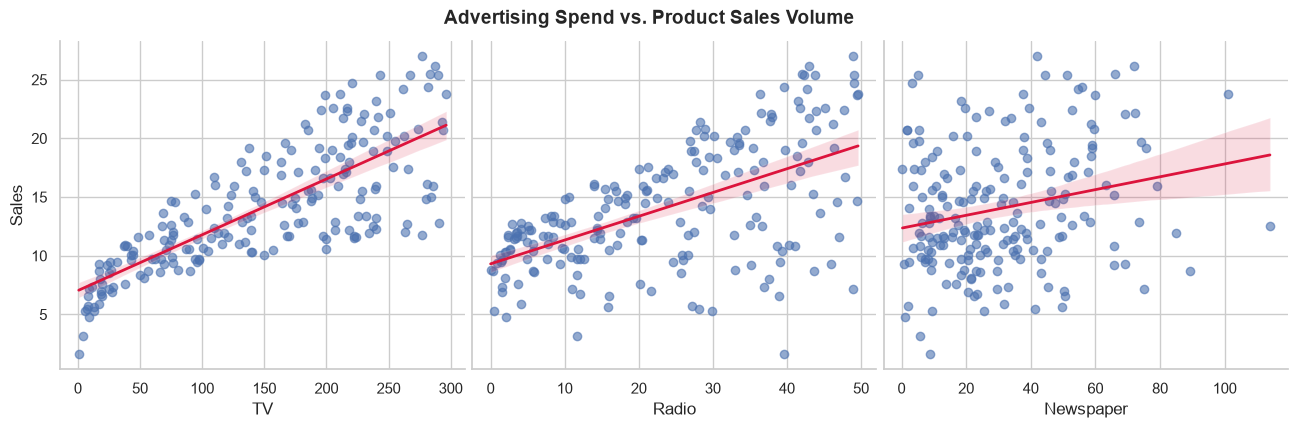

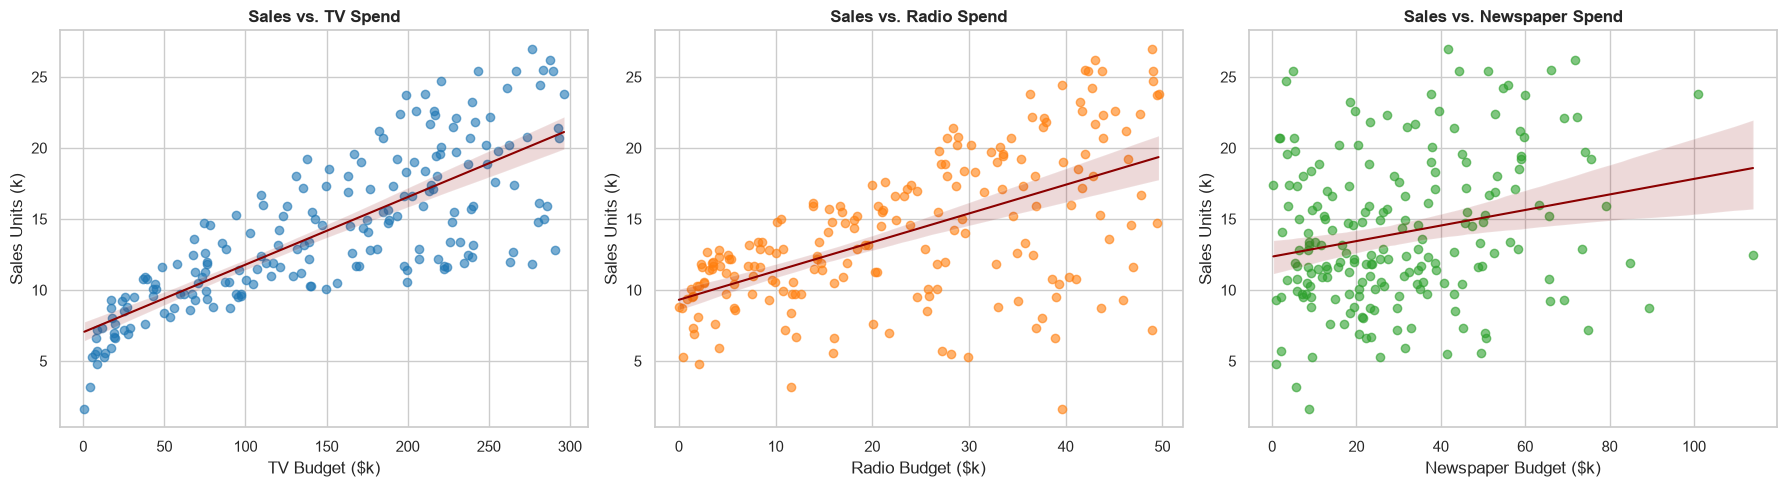

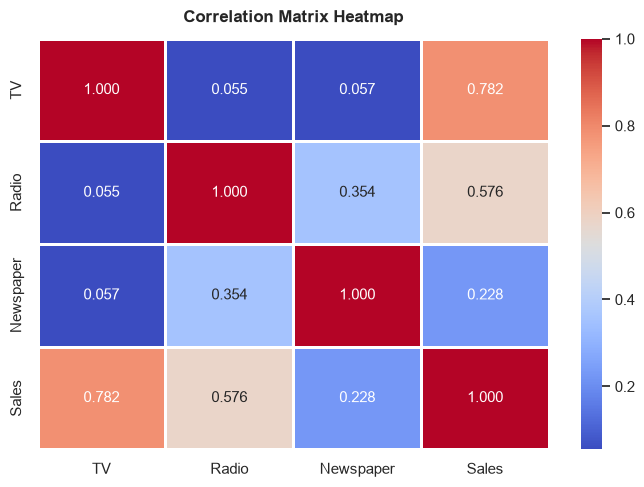

In [13]:
## Step 3: Exploratory Data Analysis & Relationship Inspection
##1. **Pairplot:** Multi-variable pairwise distributions across all features.
##2. **Individual Scatter Plots:** Linear regressions isolating Sales against TV, Radio, and Newspaper expenditures.
##3. **Correlation Heatmap:** Linear correlation matrix diagnosing cross-feature relationships.

# 1. Normalize and clean column names to prevent any KeyError
df.columns = df.columns.str.strip().str.capitalize()
df.rename(columns={'Tv': 'TV'}, inplace=True)

unnamed_cols = [c for c in df.columns if 'unnamed' in c.lower()]
if unnamed_cols:
    df.drop(columns=unnamed_cols, inplace=True)

# 2. Pairplot across all advertising channels vs Sales
pairplot_fig = sns.pairplot(
    df,
    x_vars=['TV', 'Radio', 'Newspaper'],
    y_vars='Sales',
    height=4,
    aspect=1.1,
    kind='reg',
    plot_kws={'line_kws': {'color': 'crimson', 'linewidth': 2}, 'scatter_kws': {'alpha': 0.6}}
)
pairplot_fig.fig.suptitle("Advertising Spend vs. Product Sales Volume", y=1.05, weight='bold', size=14)
plt.show()

# 3. Individual Scatter Plots for each media channel
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
channels = ['TV', 'Radio', 'Newspaper']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, channel, color in zip(axes, channels, colors):
    sns.regplot(
        data=df,
        x=channel,
        y='Sales',
        ax=ax,
        color=color,
        scatter_kws={'alpha': 0.6},
        line_kws={'color': 'darkred', 'linewidth': 1.5}
    )
    ax.set_title(f"Sales vs. {channel} Spend", weight='bold')
    ax.set_xlabel(f"{channel} Budget ($k)")
    ax.set_ylabel("Sales Units (k)")

plt.tight_layout()
plt.show()

# 4. Correlation Matrix Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".3f",
    linewidths=1.0,
    cbar=True
)
plt.title("Correlation Matrix Heatmap", weight='bold', pad=12)
plt.tight_layout()
plt.show()

In [16]:
## Step 4: Dataset Splitting
##Segment independent predictors ($X = [\text{TV}, \text{Radio}, \text{Newspaper}]$) from the target vector ($y = \text{Sales}$) using an 80/20 train/test split.
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]} (80%)")
print(f"Testing samples:  {X_test.shape[0]} (20%)")                                                                                                          

Training samples: 160 (80%)
Testing samples:  40 (20%)


In [18]:
## Step 5: Model Training & Evaluation
##Train Multiple Linear Regression as the baseline and Random Forest Regressor as the non-linear ensemble model. Evaluate both using MAE, RMSE, and $R^2$.
models = {
    "Linear Regression (Baseline)": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

benchmark_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    benchmark_results.append({
        "Model": name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R² Score": round(r2, 4)
    })

benchmark_df = pd.DataFrame(benchmark_results)
display(benchmark_df)

,Model,MAE,RMSE,R² Score
0,Linear Regression (Baseline),1.4608,1.7816,0.8994
1,Random Forest Regressor,0.6203,0.7687,0.9813


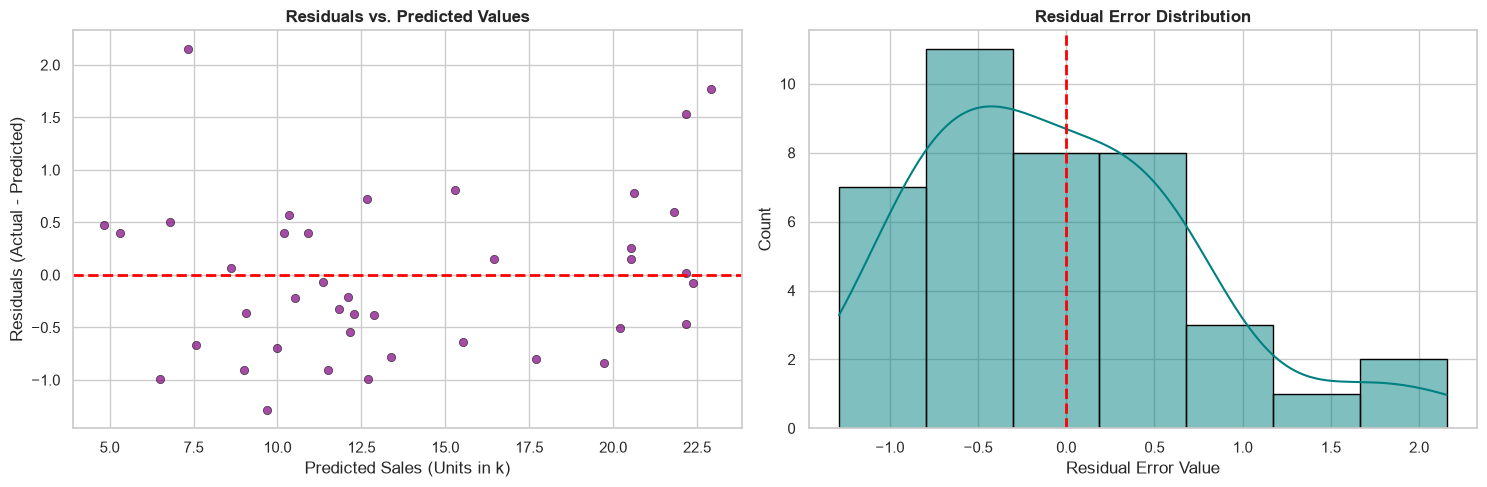

Mean of Residuals: -0.0310 (Close to 0 confirms unbiased predictions)
Standard Deviation of Residuals: 0.7779


In [20]:
## Step 6: Residual Diagnostics for Best Model
##We diagnose residuals ($y_{\text{test}} - \hat{y}_{\text{pred}}$) for our top-performing model (Random Forest Regressor) to evaluate two key regression assumptions:
##1. **Homoscedasticity:** Errors should be randomly scattered around zero with constant variance across all predicted values.
##2. **Normality of Errors:** Residuals should roughly follow a bell curve centered at zero without severe skewness or systematic bias.
# Select best model and compute residuals
best_model = models["Random Forest Regressor"]
y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Residuals vs. Predicted Values (Homoscedasticity Check)
sns.scatterplot(x=y_pred_best, y=residuals, ax=axes[0], color='purple', alpha=0.7, edgecolor='black')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title("Residuals vs. Predicted Values", weight='bold')
axes[0].set_xlabel("Predicted Sales (Units in k)")
axes[0].set_ylabel("Residuals (Actual - Predicted)")

# 2. Residual Distribution Curve
sns.histplot(residuals, kde=True, ax=axes[1], color='teal', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Residual Error Distribution", weight='bold')
axes[1].set_xlabel("Residual Error Value")

plt.tight_layout()
plt.show()

# Residual summary metrics
print(f"Mean of Residuals: {residuals.mean():.4f} (Close to 0 confirms unbiased predictions)")
print(f"Standard Deviation of Residuals: {residuals.std():.4f}")

Linear Regression Coefficients:


,Channel,Linear Coefficient
1,Radio,0.189195
0,TV,0.044730
2,Newspaper,0.002761



Random Forest Feature Importances:


,Channel,Random Forest Importance
0,TV,0.624810
1,Radio,0.362214
2,Newspaper,0.012976


C:\Users\hp\AppData\Local\Temp\ipykernel_12816\458255971.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coeff_df, x='Channel', y='Linear Coefficient', ax=axes[0], palette='Blues_d')
C:\Users\hp\AppData\Local\Temp\ipykernel_12816\458255971.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importance, x='Channel', y='Random Forest Importance', ax=axes[1], palette='Greens_d')


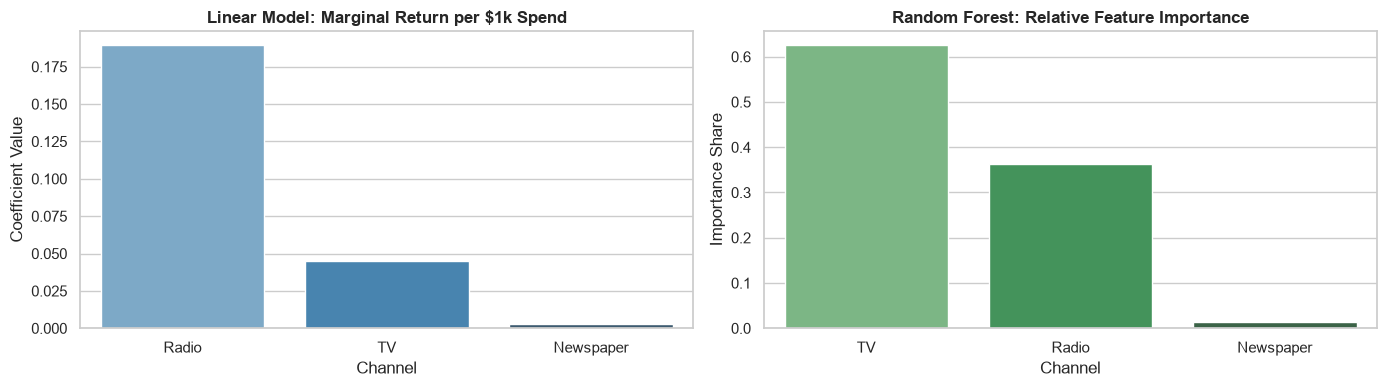

In [22]:
## Step 7: Channel Impact Interpretation & Attribution
##We identify which advertising channel drives product sales by inspecting:
##1. **Linear Regression Coefficients:** Demonstrates the direct marginal increase in units sold per $1,000 spend increase.
##2. **Random Forest Feature Importance:** Quantifies each channel's contribution across decision tree splits.
# Extract Linear Regression Coefficients
lr_model = models["Linear Regression (Baseline)"]
coeff_df = pd.DataFrame({
    'Channel': X.columns,
    'Linear Coefficient': lr_model.coef_
}).sort_values(by='Linear Coefficient', ascending=False)

# Extract Random Forest Feature Importances
rf_importance = pd.DataFrame({
    'Channel': X.columns,
    'Random Forest Importance': best_model.feature_importances_
}).sort_values(by='Random Forest Importance', ascending=False)

print("Linear Regression Coefficients:")
display(coeff_df)

print("\nRandom Forest Feature Importances:")
display(rf_importance)

# Visualizing Feature Impact
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=coeff_df, x='Channel', y='Linear Coefficient', ax=axes[0], palette='Blues_d')
axes[0].set_title("Linear Model: Marginal Return per $1k Spend", weight='bold')
axes[0].set_ylabel("Coefficient Value")

sns.barplot(data=rf_importance, x='Channel', y='Random Forest Importance', ax=axes[1], palette='Greens_d')
axes[1].set_title("Random Forest: Relative Feature Importance", weight='bold')
axes[1].set_ylabel("Importance Share")

plt.tight_layout()
plt.show()

In [24]:
## Step 8: Live Revenue Simulation
##Simulate projected sales volume using our trained Random Forest model on sample budget scenarios ($ in thousands).
# Sample advertising budget scenarios
budget_scenarios = pd.DataFrame({
    'TV': [230.1, 44.5, 17.2, 280.0],
    'Radio': [37.8, 39.3, 45.9, 50.0],
    'Newspaper': [69.2, 45.1, 69.3, 0.0]
})

# Generate predictions
projected_sales = best_model.predict(budget_scenarios)
budget_scenarios['Projected Sales (Units in k)'] = projected_sales.round(2)

print("Live Budget Simulation Results:")
display(budget_scenarios)

Live Budget Simulation Results:


,TV,Radio,Newspaper,Projected Sales (Units in k)
0,230.1,37.8,69.2,21.99
1,44.5,39.3,45.1,10.72
2,17.2,45.9,69.3,8.71
3,280.0,50.0,0.0,25.65


In [25]:
## Step 9: Artifact Export
##Save model evaluation metrics to a CSV summary table.
benchmark_df.to_csv("model_performance_summary.csv", index=False)
print("Pipeline complete. Benchmark metrics successfully exported to 'model_performance_summary.csv'.")

Pipeline complete. Benchmark metrics successfully exported to 'model_performance_summary.csv'.
